C:\Users\Harshitha.M\AppData\Local\Temp\ipykernel_18612\2250370692.py:39: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


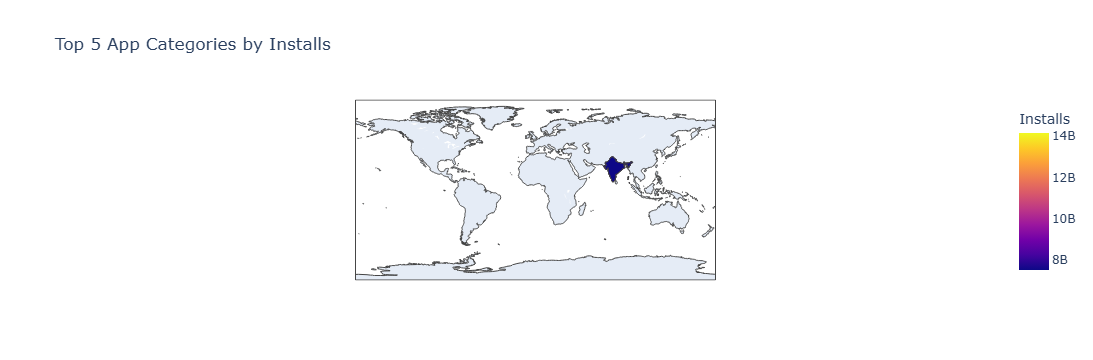

In [1]:
import pandas as pd
import plotly.express as px
from datetime import datetime

# Load dataset
df = pd.read_csv(r"C:\Users\Harshitha.M\Downloads\Play Store Data (1).csv")

# Clean Installs column
df["Installs"] = df["Installs"].astype(str)
df["Installs"] = df["Installs"].str.replace("+", "", regex=False)
df["Installs"] = df["Installs"].str.replace(",", "", regex=False)
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

# Remove categories starting with A, C, G, or S
df = df[~df["Category"].str.startswith(("A", "C", "G", "S"), na=False)]

# Calculate total installs for each category
category_installs = df.groupby("Category")["Installs"].sum().reset_index()

# Keep only categories with installs greater than 1 million
category_installs = category_installs[
    category_installs["Installs"] > 1000000
]

# Select top 5 categories
category_installs = category_installs.sort_values(
    by="Installs",
    ascending=False
).head(5)

# Time condition
current_hour = datetime.now().hour

if 18 <= current_hour < 20:

    # Since there is no country column, use a world choropleth with dummy location
    category_installs["Country"] = "India"

    fig = px.choropleth(
        category_installs,
        locations="Country",
        locationmode="country names",
        color="Installs",
        hover_name="Category",
        title="Top 5 App Categories by Installs"
    )

    fig.show()

else:
    print("This graph is available only between 6 PM and 8 PM IST.")